# Анализ результатов A/B теста

## Пояснительная записка:

Цель эксперимента: Оценить влияние нового алгоритма рекомендации постов на поведение пользователей.

Дизайн эксперимента:
 - Для эксперимента были задействованы группы 2 (эксперимент) и 1 (контроль). 
 - Эксперимент проходил с 2026-01-02 по 2026-01-08 включительно. 
 - Ключевая метрика: CTR

Гипотеза: Новый алгоритм во 2-й группе приведет к увеличению CTR. 

Использованы методы тестирования: t-test, тест Манна-Уитни, t-test на сглаженном ctr, Пуассоновский бутстреп, t-test и тест Манна-Уитни поверх бакетного преобразования

Результаты: t-test и t-test на сглаженном ctr не видят разницы. Тест Манна-Уитни, Пуассоновский бутстреп и бакетное преобразование показали наличие эффекта. Однако высокий разброс значений в группе 2 указывает на неоднородность реакции пользователей на новый алгоритм.

Вывод: Полное раскатывание нецелесообразно. Рекомендуется сегментный анализ пользователей и поэтапное внедрение алгоритма. 

### Анализ

In [1]:
import pandas as pd
import pandahouse
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import os

def load_env(path):
    with open(path) as f:
        for line in f:
            key, value = line.strip().split("=", 1)
            os.environ[key] = value

load_env("AB test/config.env")

In [3]:
connection = {
    'host': os.getenv('DB_HOST'),
    'user': os.getenv('DB_USER'),
    'password': os.getenv('DB_PASSWORD'),
    'database': os.getenv('DB_DATABASE')
}

In [4]:
q = """
SELECT exp_group, 
   user_id,
   sum(action = 'like') as likes,
   sum(action = 'view') as views,
   likes/views as ctr
FROM {db}.feed_actions 
WHERE toDate(time) between '2026-01-02' and '2026-01-08'
   and exp_group in (2,1)
GROUP BY exp_group, user_id
"""

In [5]:
users_df = pandahouse.read_clickhouse(q, connection=connection)
users_df

,exp_group,user_id,likes,views,ctr
0,1,109963,3,15,0.200000
1,1,26117,32,141,0.226950
2,1,138232,18,73,0.246575
3,1,26295,39,141,0.276596
4,1,18392,7,32,0.218750
...,...,...,...,...,...
19892,2,17146,0,10,0.000000
19893,1,30872,11,59,0.186441
19894,2,25383,42,127,0.330709
19895,2,139020,17,41,0.414634


In [6]:
#разделили экспериментальную и контрольную группы
group_2_exp = users_df[users_df['exp_group']==2]
group_1_ctrl = users_df[users_df['exp_group']==1]



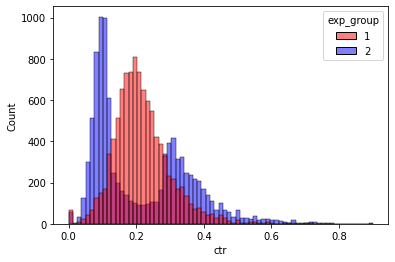

In [7]:
# распределение ctr по группам
groups = sns.histplot(data = users_df, 
x='ctr', 
hue='exp_group', 
palette = ['r', 'b'],
alpha=0.5,
kde=False)

In [8]:
print(f' средний CTR экспериментальной группы 2: {group_2_exp.ctr.mean()}')
print(f' средний CTR контрольной группы 1: {group_1_ctrl.ctr.mean()}')

print(f' медианный CTR экспериментальной группы 2: {group_2_exp.ctr.median()}')
print(f' медианный CTR контрольной группы 1: {group_1_ctrl.ctr.median()}')

 средний CTR экспериментальной группы 2: 0.2161016893237817
 средний CTR контрольной группы 1: 0.216773994120072
 медианный CTR экспериментальной группы 2: 0.1532846715328467
 медианный CTR контрольной группы 1: 0.2058823529411764



Промежуточные выводы:

1. CTR контрольной группы имеет нормальное распределение: пользователи лайкают примерно одинаково.
2. В экспериментальной группе распределение CTR бимодальное: увеличилось число пользователей, кликающих чаще (высокий CTR), и увеличилось число пользователей, лайкающих реже (низкий CTR).
3. Среденее значение CTR почти не отличается, тогда как медианное значение немного сдвинулось влево в экспериментальной группе ("типичный" пользователь ставит лайки реже). 

# T-test

In [9]:
#t-test

stat, p_value = stats.ttest_ind(
    group_2_exp.ctr,
    group_1_ctrl.ctr,
    equal_var=False
)

if p_value < 0.05:
    print(f' p-value: {p_value}, Разница статистически значима')
else:
    print(f' p-value: {p_value}, Статистически значимой разницы нет')

 p-value: 0.685373331140751, Статистически значимой разницы нет


T-test смотрит разницу на средних значениях. Статистически значимой разницы по средним значениям не обнаружено.

# Тест Манна-Уитни

In [10]:
#тест Манна-Уитни

stat, p_value = stats.mannwhitneyu(
    group_2_exp.ctr, 
    group_1_ctrl.ctr, 
    alternative = 'two-sided')


if p_value < 0.05:
    print(f' p-value: {p_value}, Разница статистически значима')
else:
    print(f' p-value: {p_value}, Статистически значимой разницы нет')

 p-value: 4.632205841806026e-45, Разница статистически значима


Тест Манна-Уитни чувствителен к разным распределениям данных и показывает, что эффект есть.

# t-тест на сглаженном ctr (α=5)

In [11]:
def get_smoothed_ctr(user_likes, user_views, global_ctr, alpha):
    smoothed_ctr = (user_likes + alpha * global_ctr) / (user_views + alpha)
    return smoothed_ctr

In [12]:
global_ctr_1 = group_1_ctrl.likes.sum()/group_1_ctrl.views.sum()

global_ctr_2 = group_2_exp.likes.sum()/group_2_exp.views.sum()



In [13]:
global_ctr_1, global_ctr_2

(0.2096041628394293, 0.20025051027061783)

<Axes: xlabel='ctr', ylabel='Count'>

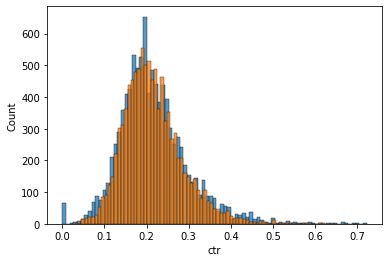

In [14]:
group_1 = group_1_ctrl.copy()
sns.histplot(group_1.ctr, kde = False)

group_1['smoothed_ctr'] = group_1.apply(
    lambda x: get_smoothed_ctr(x['likes'], x['views'], global_ctr_1, 5), 
    axis=1)

sns.histplot(group_1.smoothed_ctr, kde = False)

<Axes: xlabel='ctr', ylabel='Count'>

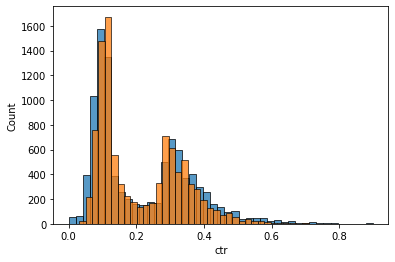

In [15]:
group_2 = group_2_exp.copy()
sns.histplot(group_2.ctr, kde = False)

group_2['smoothed_ctr'] = group_2.apply(
    lambda x: get_smoothed_ctr(x['likes'], x['views'], global_ctr_2, 5), 
    axis=1)

sns.histplot(group_2.smoothed_ctr, kde = False)

In [16]:
#t-test на сглаженном CTR

stat, p_value = stats.ttest_ind(
    group_2.ctr,
    group_1.ctr,
    equal_var=False
)

if p_value < 0.05:
    print(f' p-value: {p_value}, Разница статистически значима')
else:
    print(f' p-value: {p_value}, Статистически значимой разницы нет')

 p-value: 0.685373331140751, Статистически значимой разницы нет


После снижения шумов в данных t-test все равно не видит разницы, т.к. у нас не нормальное распределение данных экспериментальной группы.

# Пуассоновский бутстреп

<Axes: ylabel='Count'>

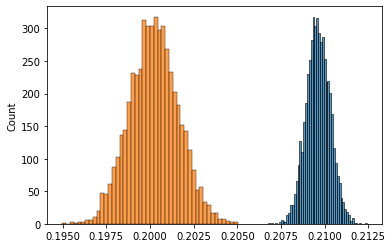

In [17]:
#Пуассоновский бутстреп

def bootstrap(likes1, views1, likes2, views2, n_bootstrap=5000):
    w1 = stats.poisson(1).rvs((n_bootstrap, len(likes1)))
    w2 = stats.poisson(1).rvs((n_bootstrap, len(likes2)))

    ctr1 = (w1 * likes1).sum(axis=1) / (w1 * views1).sum(axis=1)
    ctr2 = (w2 * likes2).sum(axis=1) / (w2 * views2).sum(axis=1)

    return ctr1, ctr2

likes1 = group_1_ctrl.likes.to_numpy()
views1 = group_1_ctrl.views.to_numpy()
likes2 = group_2_exp.likes.to_numpy()
views2 = group_2_exp.views.to_numpy()
ctr1, ctr2 = bootstrap(likes1, views1, likes2, views2)
sns.histplot(ctr1)
sns.histplot(ctr2)

<Axes: ylabel='Count'>

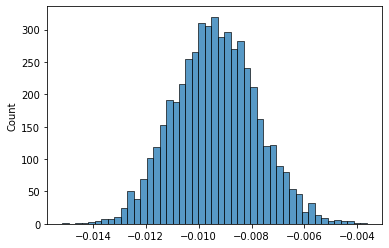

In [18]:
#Разница между глобальными CTR
sns.histplot(ctr2 - ctr1)

In [19]:
print(f' Доверительный интервал: {np.percentile(ctr2 - ctr1, [2.5, 97.5])}')

 Доверительный интервал: [-0.01239391 -0.00625852]


Экспериментальная группа показывает чуть более высокий CTR по сравнению с контрольной.
0 (то есть отсутствие эффекта) не попадает в доверительный интервал, т.о. эффект есть.

# t-test и тест Манна-Уитни поверх бакетного преобразования

In [20]:
q = """
SELECT exp_group, bucket,
   sum(likes)/sum(views) as bucket_ctr,
   quantileExact(0.9)(ctr) as ctr9
FROM (SELECT exp_group, 
       xxHash64(user_id)%50 as bucket,
       user_id,
       sum(action = 'like') as likes,
       sum(action = 'view') as views,
       likes/views as ctr
   FROM {db}.feed_actions 
   WHERE toDate(time) between '2026-01-02' and '2026-01-08'
       and exp_group in (1,2)
   GROUP BY exp_group, bucket, user_id)
GROUP BY exp_group, bucket
"""
df = pandahouse.read_clickhouse(q, connection=connection)

In [21]:
df = pandahouse.read_clickhouse(q, connection=connection)

#тест Манна-Уитни видит отличие
stat, p_value = stats.mannwhitneyu(
    df[df.exp_group == 1].bucket_ctr, 
    df[df.exp_group == 2].bucket_ctr, 
    alternative = 'two-sided')


if p_value < 0.05:
    print(f' Тест Манна-Уитни поверх бакетного преобразования, p-value: {p_value}, Разница статистически значима')
else:
    print(f' Тест Манна-Уитни поверх бакетного преобразования, p-value: {p_value}, Статистически значимой разницы нет')

#и t-тест тоже
stat, p_value = stats.ttest_ind(
    df[df.exp_group == 1].bucket_ctr, 
    df[df.exp_group == 2].bucket_ctr, 
    equal_var = False)

if p_value < 0.05:
    print(f' t-test поверх бакетного преобразования, p-value: {p_value}, Разница статистически значима')
else:
    print(f' t-test поверх бакетного преобразования, p-value: {p_value}, Статистически значимой разницы нет')

 Тест Манна-Уитни поверх бакетного преобразования, p-value: 2.6576427804010095e-07, Разница статистически значима
 t-test поверх бакетного преобразования, p-value: 4.592644937473873e-07, Разница статистически значима


<Axes: xlabel='bucket_ctr', ylabel='Count'>

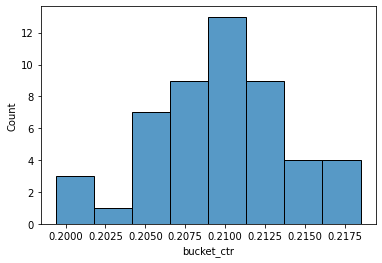

In [22]:
sns.histplot(df[df.exp_group == 1].bucket_ctr)

<Axes: xlabel='ctr9', ylabel='Count'>

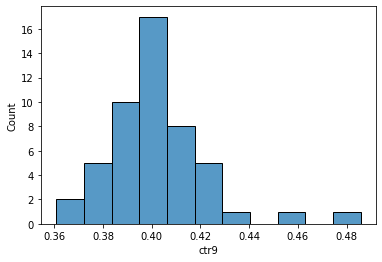

In [23]:
sns.histplot(df[df.exp_group == 2].ctr9)

Бакетное преобразование показало наличие эффекта.

Общий вывод:
1. По результатам тестов показатель метрики CTR статистически немного увеличился.
2. Но пользователи в экспериментальной группе слишком по-разному реагируют на новый алгоритм, можно предположить разные сегменты пользователей в экспериментальной группе.
3. Раскатывать новый алгоритм на всех пользователей не стоит. Рекомендуется проанализировать сегменты пользователей, где проявилась положительная динамика и раскатать новый алгоритм сначала на них.